In [12]:
from ovito.io import *
from ovito.modifiers import *
from ovito.data import *
from ovito.pipeline import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from ovito.pipeline import StaticSource, Pipeline
from ovito.io.ase import ase_to_ovito
import seaborn as sns
from ase import Atoms
import os
import sys

repo_root = os.path.abspath(os.path.join(os.getcwd(), "../src"))
sys.path.append(repo_root)
from df_gen import *

mpl.rcParams['figure.dpi'] = 300
plt.style.use('../src/plot.mplstyle')
cm = 1/2.54

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
df=pd.read_pickle('../data/xyz/df_npt_anneal_293K_10ps_-1_generated.pckl.gzip',compression="gzip")
df.columns


Index(['ase_atoms', 'nb_atoms', 'size', 'vol_per_atom', 'label', 'Category_2',
       'Category_color_2', 'mtp_energy', 'dE_mtp', 'mtp_at_E_NN', 'forces',
       'F_max', 'soap_sim_cSi', 'atomistic_soap_sim_cSi', 'CNA', 'ptm_cat'],
      dtype='object')

In [7]:
def soap_cat(row):
    soap=row['soap_sim_cSi']
    return np.round(soap, 2)[0][0]

In [8]:
# Select subset of structures of 1000 atoms that have crystalline environments, and sort them into bins of SOAP similarity
df['soap_cat']=df.apply(soap_cat, axis=1).tolist()
df_para=df[df['ptm_cat']=='Crystalline']
df_para=df_para[df_para['nb_atoms']==1000]
df_para=df_para.reset_index(drop=True)


In [14]:
# Cluster analysis
results = df_para.apply(cluster_analysis, axis=1).tolist()
df_para[['cluster_sizes', 'av_cluster_size', 'av_nb_cluster', 'av_dist', 'all_dist', 'av_dist_cm', 'all_dist_cm']] = pd.DataFrame(results, index=df_para.index)

soap_cats, counts=np.unique(df_para.soap_cat, return_counts=True)

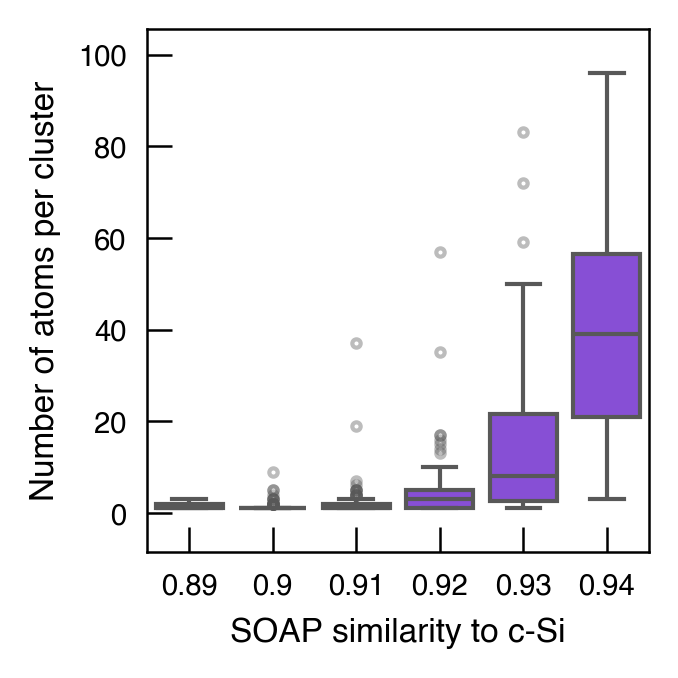

In [15]:
# Panel a, only showing paracrystalline structures

fig, ax = plt.subplots(1, 1, figsize=(6 * cm, 6 * cm))

for cat in soap_cats[1:-6]: # only showing paracrystalline structures
    nb_atoms=np.asarray([value[0] for value in df_para[df_para['soap_cat']==cat].cluster_sizes.values])
    sns.boxplot(y=nb_atoms, x=cat, color='#8338EC', linewidth=1, flierprops=dict(markersize=2, linestyle='none', alpha=0.4)) 

plt.xlabel('SOAP similarity to c-Si')
plt.ylabel('Number of atoms per cluster')
plt.yticks(np.arange(0,120,20))
plt.tight_layout()

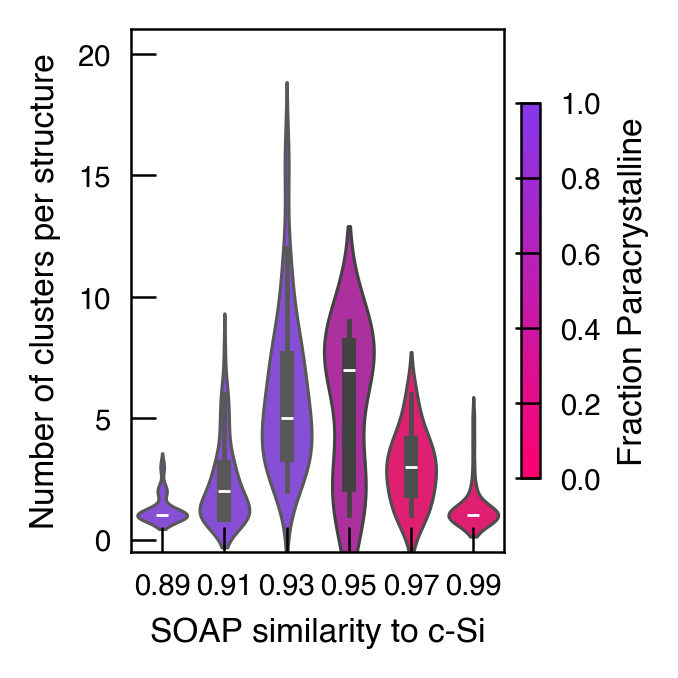

In [18]:
# Panel b

cmap = mpl.colors.LinearSegmentedColormap.from_list("", ['#FF006E', '#8338EC'])
norm = mpl.colors.Normalize(vmin=0, vmax=1)  # Normalize pct values between 0 and 1

# Create the figure and axis
fig, ax = plt.subplots(1, 1, figsize=(6 * cm, 6 * cm))

for cat in soap_cats[1:-1:2]:
    nb_clusters=np.asarray(df_para[df_para['soap_cat']==cat].av_nb_cluster.values)

    pct = df_para[df_para['soap_cat'] == cat].Category_2.value_counts().get('Paracrystalline', 0) / \
          (df_para[df_para['soap_cat'] == cat].Category_2.value_counts().get('Paracrystalline', 0) +
           df_para[df_para['soap_cat'] == cat].Category_2.value_counts().get('Polycrystalline', 0))
    color = cmap(norm(pct))
    
    # print(all_dist)
    sns.violinplot(y=nb_clusters, x=cat, color=color, bw_adjust=1, )#, common_norm=False, bw_adjust=1)
    data_to_save = np.vstack((np.repeat(cat, len(nb_clusters)), nb_clusters)).T
    np.savetxt(f"/Users/louiserosset/Documents/Paracrystallinity/Raw_data/fig3-b)-{cat}.csv", data_to_save, delimiter="," ,fmt=["%.2f", "%.0f"])

# Create a ScalarMappable for the color bar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add the color bar to the figure
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label("Fraction Paracrystalline")
plt.xlabel('SOAP similarity to c-Si')
plt.ylabel('Number of clusters per structure')
mpl.rcParams['xtick.labelsize'] = 7

# plt.legend()
plt.ylim(bottom=-0.5)
plt.yticks(np.arange(0,25,5))
plt.tight_layout()

/Users/louiserosset/software/miniconda3/envs/envase/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/louiserosset/software/miniconda3/envs/envase/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/louiserosset/software/miniconda3/envs/envase/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


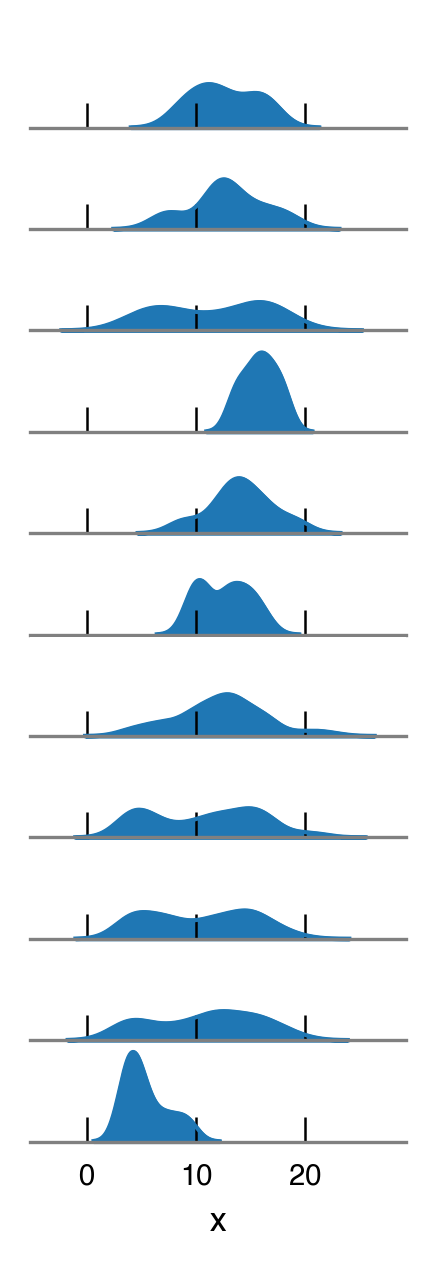

In [20]:
# Panel c

all_dists_cats=np.array(())
all_cats=np.array(())

for cat in soap_cats[1:-1]:
    all_dist=np.asarray([value[0] for value in df_para[df_para['soap_cat']==cat].all_dist.values])
    all_dist=all_dist=np.delete(np.unique(all_dist), 0).flatten()
    all_dists_cats=np.concatenate([all_dists_cats, all_dist])
    cats=np.repeat(cat, len(all_dist))
    all_cats=np.concatenate([all_cats, cats])


df = pd.DataFrame(dict(x=all_dists_cats, g=all_cats))
df['g'] = pd.Categorical(df['g'], categories=sorted(df['g'].unique(), reverse=True), ordered=True)

pal = sns.cubehelix_palette(10, rot=-.25, light=.9)
pal = sns.color_palette("blend:#FF006E,#8338EC", as_cmap=True)
g = sns.FacetGrid(df, row="g", aspect=4.5, height=1*cm, palette=pal)

g.map(sns.kdeplot, "x",
      bw_adjust=.75, clip_on=False,
      fill=True, alpha=1, linewidth=1, color='k')
g.map(sns.kdeplot, "x", clip_on=True, color="k", lw=1, bw_adjust=.75)
g.refline(y=0, linewidth=0.8, linestyle="-", color='k', clip_on=False)

g.figure.subplots_adjust(hspace=0.03)

g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
